# Business Domain Analysis: Medical Insurance Cost Prediction

## Business Objective

The goal is to **predict individual medical insurance charges** using demographic and health-related data. This helps insurance companies:

- Assess risk and set premiums accurately
- Segment customers
- Detect fraud
- Offer personalized insurance products

---

## Data Attributes & Business Relevance

| Feature    | Type         | Description | Business Value |
|------------|--------------|-------------|----------------|
| `age`      | Numerical    | Age of the primary beneficiary | Older age often correlates with higher medical costs |
| `sex`      | Categorical  | Gender (male/female) | May show cost trends across genders |
| `bmi`      | Numerical    | Body Mass Index (kg/m²) | High BMI is a risk factor for costly conditions |
| `children` | Numerical    | Number of dependents | More dependents may lead to higher total costs |
| `smoker`   | Categorical  | Smoker or non-smoker | Smoking strongly increases expected charges |
| `region`   | Categorical  | Region in the US (northeast, southeast, etc.) | Costs may vary by region due to healthcare access and pricing |
| `charges`  | Numerical    | Insurance charges (target variable) | Used to train and validate predictive models |

---

## Business Use Cases

### 1. Dynamic Pricing
Use predicted `charges` to assign risk-based premiums, rewarding healthy behavior (e.g., non-smokers).

### 2. Customer Segmentation
Segment customers by age, BMI, smoking, etc., to offer personalized plans.

### 3. Cost Forecasting
Improve actuarial models and financial planning by predicting future claims.

### 4. Fraud Detection
Flag anomalies between expected and actual costs for potential investigation.

---

## Target Variable Analysis

- `charges` is a **continuous numerical variable** (regression target).
- Typically **right-skewed** with a long tail for high-cost patients.

---

## Modeling Considerations

- Use **regression models** (Linear Regression, Random Forest, XGBoost).
- Handle categorical variables with **one-hot encoding**.
- Scale or transform skewed numerical variables like BMI and charges.
- Evaluate performance with metrics like **RMSE**, **MAE**, and **R²**.

---

## Summary

| Aspect       | Summary |
|--------------|---------|
| **Goal**     | Predict medical charges based on personal and health info |
| **Key Features** | Age, BMI, Smoking, Region |
| **Target**   | `charges` |
| **ML Type**  | Supervised Regression |
| **Stakeholders** | Insurers, analysts, actuaries |
 

## Importing Necessary Libraries 

In [1]:
# Importing required libraries/modules 
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 

## Loading the Dataset 

In [2]:
data = pd.read_csv("datasets_13720_18513_insurance(1).csv")  # Loading dataset from CSV into a pandas DataFrame 

## Basic Check 

In [3]:
data.head() # Showing first few rows for a quick glance at structure 

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
data.info()  # Inspecting dtypes and non-null counts 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
data.isnull().sum() 

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
data.describe() # Getting summary statistics to understand numeric distributions 

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


- The ages of the individuals range from 18 to 64 years, with an average age of approximately 39 years. The age distribution shows that 25% of the individuals are younger than 27 years, while 75% are younger than 51 years. This indicates that the dataset primarily consists of working-age adults.

- BMI values range from 15.96 to 53.13, with an average BMI of 30.66. The median BMI is 30.4, indicating that a significant portion of the population is in the overweight category, which could have implications for health-related costs.

- The number of children ranges from 0 to 5, with an average of approximately 1.1 children per individual. About 25% of individuals have no children, and 75% have two or fewer children.

- The insurance charges vary widely from 1,121 to 63,770. The average charge is 13,270, while the median is 9,382. The large difference between the mean and median indicates that the distribution of charges is right-skewed, with a small number of individuals incurring very high medical expenses. 

In [7]:
data.describe(include = "O") # Getting summary statistics to understand categorical distributions 

,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


- Out of the 1,338 individuals, 1,064 are non-smokers and 274 are smokers. This shows that the majority of people in this dataset do not smoke, but the smoking group is still significant enough to study its effect on insurance charges.

- The dataset is almost evenly distributed between males and females, with 676 males and 662 females. This balance makes it suitable for comparative analysis between genders.

- The data covers four regions: southeast, southwest, northwest, and northeast. The largest group of individuals belongs to the southeast region (364), making it the most represented geographical category. 

## EDA 

### Univariate Analysis 

#### 1. For Continuous Columns: 

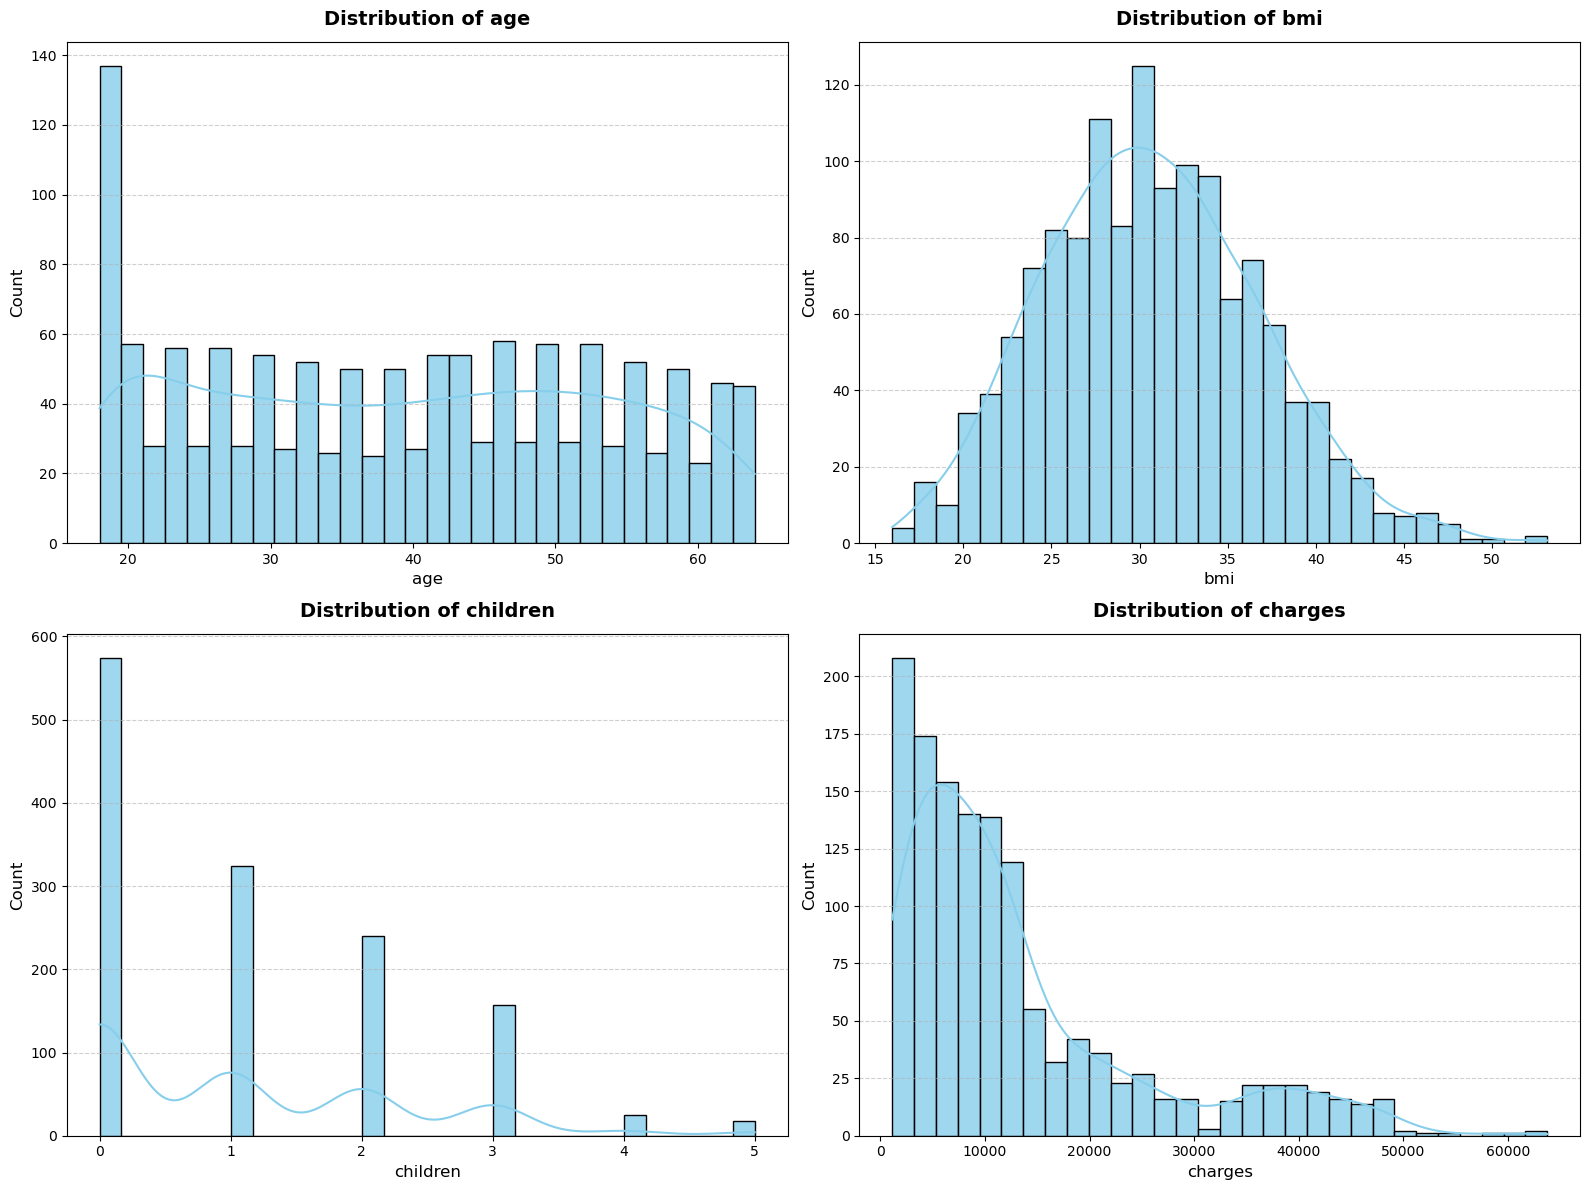

In [8]:
# Set the overall figure size
plt.figure(figsize = (16, 12))

# Select numerical columns
numerical_cols = data.select_dtypes(include = ["int", "float"]).columns  

# Loop through numerical columns and create histograms
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 2, i)
    
    # Plot histogram with KDE line
    sns.histplot(data[col], kde = True, bins = 30, color = "skyblue", edgecolor = "black", alpha = 0.8) 
    
    # Add titles and labels
    plt.title(f"Distribution of {col}", fontsize = 14, fontweight = "bold", pad = 12) 
    plt.xlabel(col, fontsize = 12)
    plt.ylabel("Count", fontsize = 12)
    
    # Light grid for better readability
    plt.grid(axis = "y", linestyle = "--", alpha = 0.6) 

# Adjust layout
plt.tight_layout()
plt.show() 

- **Age:**  
  The dataset includes individuals aged **18 to 64 years**. The distribution looks fairly uniform, though there are slightly higher frequencies in the **20–30** and **50–60** year ranges.  
  → This shows that the dataset provides a good spread across the adult age spectrum.  

- **Body Mass Index (BMI):**  
  The BMI ranges from **15.96 to 53.13**, with most values between **25 and 35**.  
  The distribution is slightly **right-skewed**, meaning a larger portion of individuals fall into the **overweight category**.  

- **Children:**  
  The number of children ranges from **0 to 5**. Most individuals have **no children** or **one to two children**, while very few have three or more.  
  → This indicates that larger families are less represented in the dataset.  

- **Insurance Charges:**  
  Medical insurance charges vary widely, from **1,121 to 63,770**.  
  The distribution is **highly right-skewed**, with most individuals paying **less than 20,000**.  
  → A small number of individuals face extremely high charges, which pulls up the overall average. 

#### 2. For Categorical Columns: 

C:\Users\KutbuddinHotel\AppData\Local\Temp\ipykernel_9596\1542454365.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = data[col], palette = "Set2", edgecolor = "black")
C:\Users\KutbuddinHotel\AppData\Local\Temp\ipykernel_9596\1542454365.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = data[col], palette = "Set2", edgecolor = "black")
C:\Users\KutbuddinHotel\AppData\Local\Temp\ipykernel_9596\1542454365.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = data[col], palette = "Set2", edgecolor = "black")


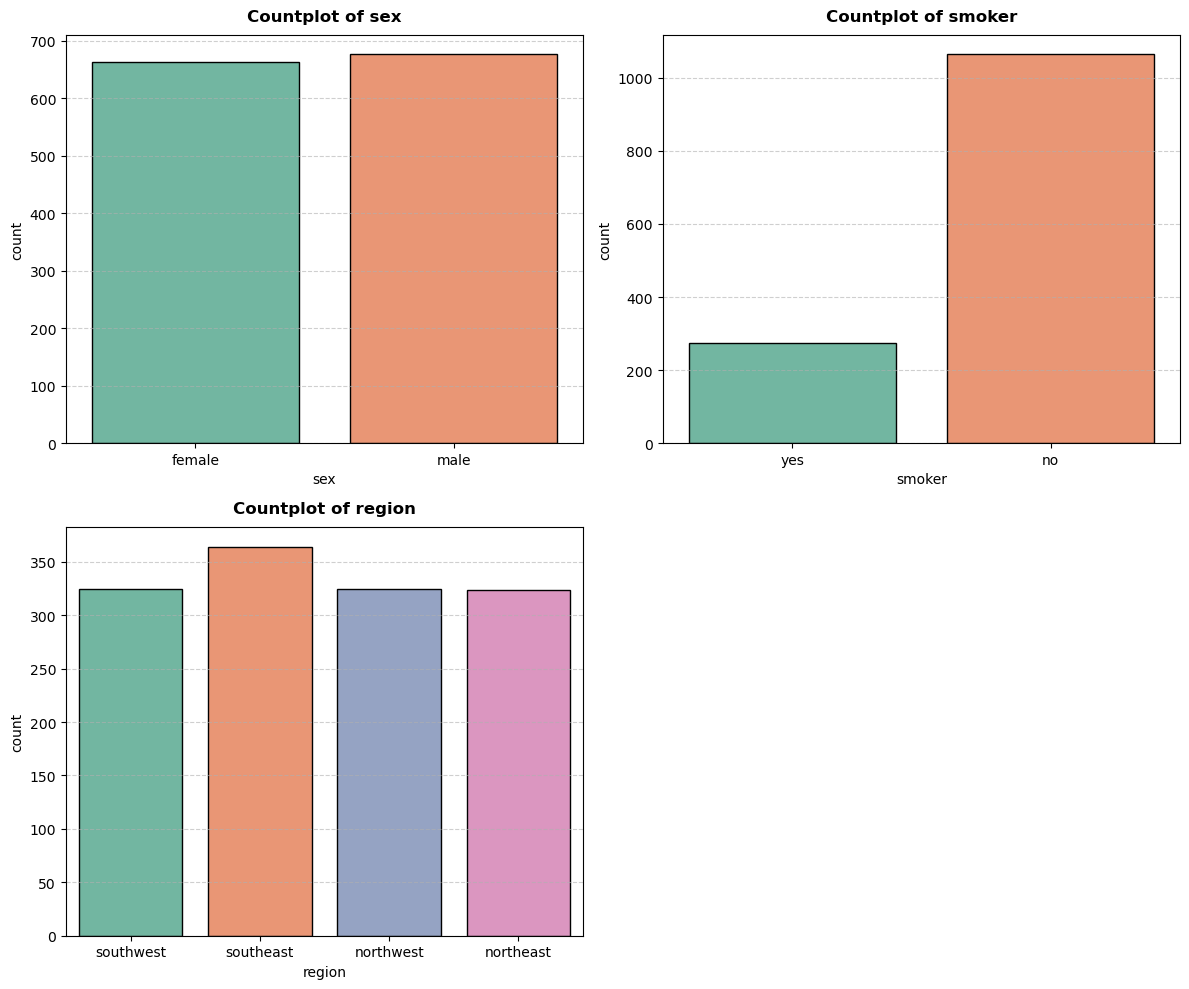

In [9]:
# Set the figure size 
plt.figure(figsize = (12, 10))  

# Select categorical columns
cat_cols_ = data.drop(data.select_dtypes(include = ["int", "float"]), axis = 1)  

# Plot count plots for categorical columns
for i, col in enumerate(cat_cols_, 1):
    plt.subplot(2, 2, i)  
    sns.countplot(x = data[col], palette = "Set2", edgecolor = "black")  
    
    # Title with spacing
    plt.title(f"Countplot of {col}", fontsize = 12, fontweight = "bold", pad = 10)  
    
    # Add gridlines only on y-axis for better readability
    plt.grid(axis = "y", linestyle = "--", alpha = 0.6)

    plt.tight_layout() 

plt.show() 

- **Sex:**  
  The dataset is almost evenly balanced between **males (50.5%)** and **females (49.5%)**.  
  This balance ensures that any **gender-based comparisons** can be made without major bias.  

- **Smoker:**  
  About **80% of individuals are non-smokers**, while **20% are smokers**.  
  Although the smoker group is smaller, it is still significant and is expected to have a **strong impact on insurance charges** because of the well-known health risks linked to smoking.  

- **Region:**  
  The individuals are spread across **four regions**: southeast, southwest, northwest, and northeast.  
  The **southeast has the largest share**, but the other regions are also **fairly well represented**, making it possible to do a meaningful **regional comparison**. 

### Bivariate Analysis 

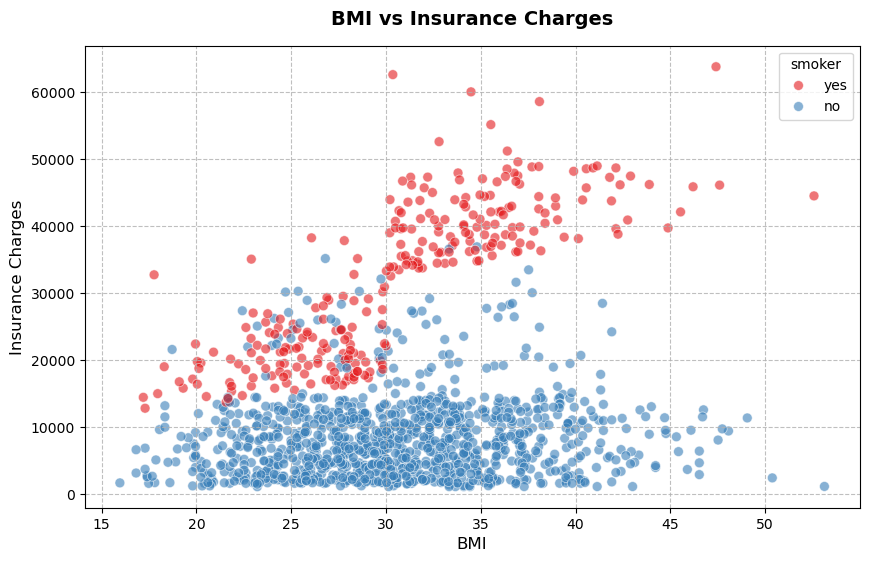

In [10]:
# Set the size of the plot 
plt.figure(figsize=(10, 6)) 

# Scatter plot
sns.scatterplot(x = data["bmi"], y = data["charges"], hue = data["smoker"], palette = "Set1", alpha = 0.6, edgecolor = "white", s = 50) 

# Title and labels 
plt.title("BMI vs Insurance Charges", fontsize = 14, fontweight = "bold", pad = 15)
plt.xlabel("BMI", fontsize = 12)
plt.ylabel("Insurance Charges", fontsize = 12)

# Light grid for readability
plt.grid(linestyle = "--", alpha = 0.8) 

plt.show() 

- **Charges vs BMI (Non-Smokers):**  
  For non-smokers, charges mostly remain **below 20,000**, and there is **no strong upward trend** with BMI.  

- **Outliers:**  
  Some individuals show **very high charges (30,000–60,000)** even at different BMI levels.  
  These cases are mostly due to **smoking**, though **age or other health conditions** could also contribute.  

- **Smokers with High BMI:**  
  Among smokers, charges **increase sharply as BMI rises**.  
  Many smokers with a **BMI above 30** face charges in the **30,000–60,000 range**.  

- **Smoking Effect:**  
  Smokers (blue dots) consistently show **much higher charges** compared to non-smokers with the same BMI.  
  → This clearly indicates that **smoking is a major factor driving insurance costs**. 

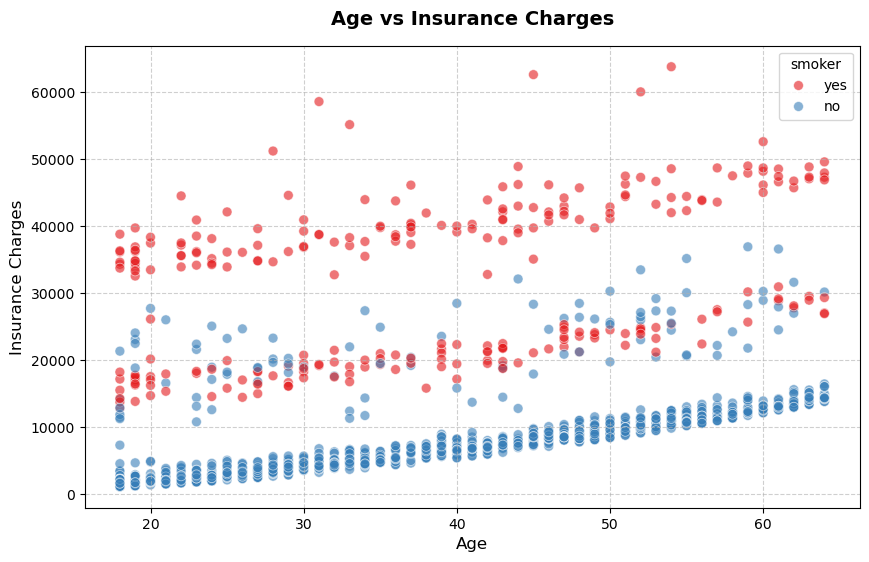

In [11]:
# Set the size of the plot
plt.figure(figsize=(10, 6))

# Scatter plot of Age vs Charges
sns.scatterplot(x = data["age"], y = data["charges"], hue = data["smoker"], palette = "Set1", alpha = 0.6, edgecolor = "white", s = 50) 

# Add title and labels
plt.title("Age vs Insurance Charges", fontsize = 14, fontweight = "bold", pad = 15) 
plt.xlabel("Age", fontsize = 12)
plt.ylabel("Insurance Charges", fontsize = 12)

# Add a grid for better readability
plt.grid(linestyle = "--", alpha = 0.6)

plt.show() 

- **Charges vs Age (General Trend):**  
  Charges **increase with age** for both smokers and non-smokers.  

- **Smoking Effect:**  
  At every age, **smokers (blue dots)** have **consistently higher charges** than non-smokers (orange dots).  
  → This clearly shows that **smoking significantly raises insurance costs**.  

- **Non-Smokers (Orange):**  
  Charges stay **comparatively low** and rise **gradually** with age.  

- **Smokers (Blue):**  
  Charges start **higher from the beginning** and rise **steeply, especially after age 30**.  

- **After Age 40:**  
  Smoker charges show **wide variation**, with many individuals facing **extremely high charges (30,000–60,000)**. 

#### Boxplots(Charges vs Categorical Variables) 

C:\Users\KutbuddinHotel\AppData\Local\Temp\ipykernel_9596\1086036083.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = data[col], y = data["charges"], palette = "pastel")
C:\Users\KutbuddinHotel\AppData\Local\Temp\ipykernel_9596\1086036083.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = data[col], y = data["charges"], palette = "pastel")
C:\Users\KutbuddinHotel\AppData\Local\Temp\ipykernel_9596\1086036083.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = data[col], y = data["charges"], palette = "pastel")


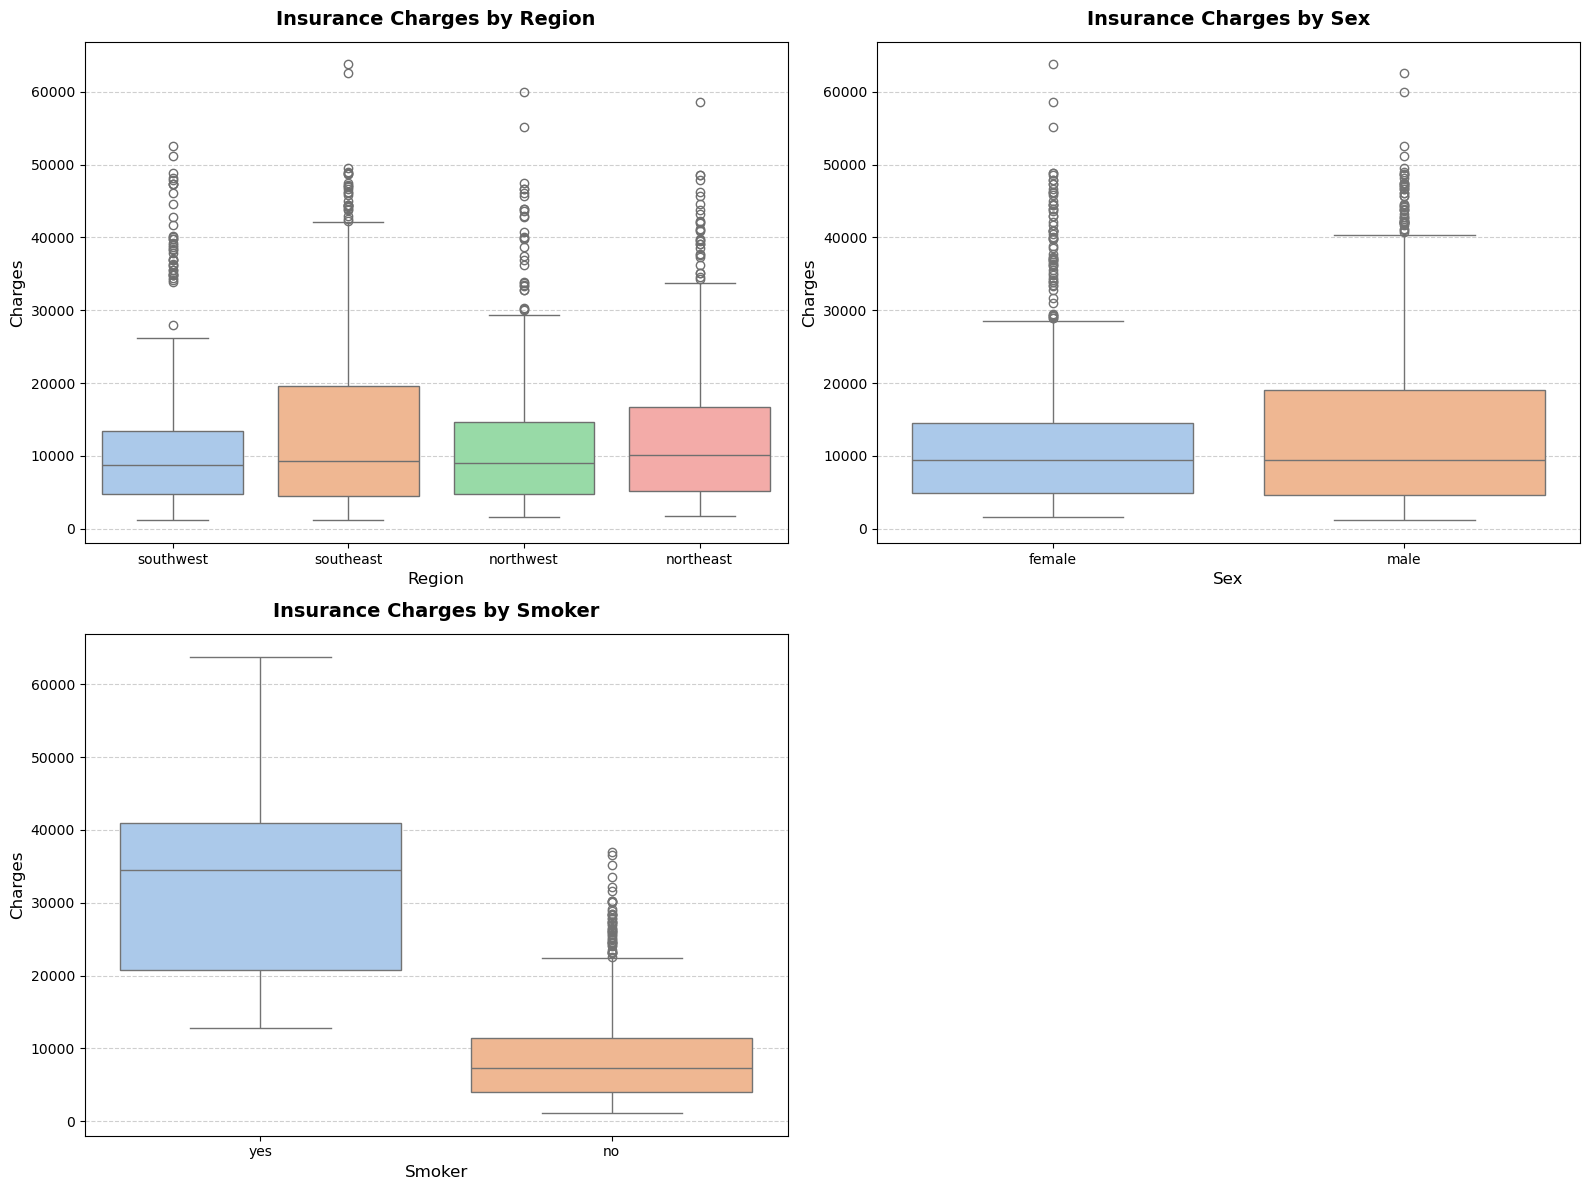

In [12]:
# Set the size of the plots
plt.figure(figsize=(16, 12))

# Define categorical columns
cat_cols = ["region", "sex", "smoker"]

# Boxplots of charges against categorical features
for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x = data[col], y = data["charges"], palette = "pastel") 

    # Add title and labels 
    plt.title(f"Insurance Charges by {col.capitalize()}", fontsize = 14, fontweight = "bold", pad = 12) 
    plt.xlabel(col.capitalize(), fontsize = 12) 
    plt.ylabel("Charges", fontsize = 12) 

    # Add gridlines for better readability
    plt.grid(axis = "y", linestyle = "--", alpha = 0.6) 

plt.tight_layout()
plt.show()  

- **Region:**  
  Insurance charges are **fairly consistent across regions**, with the **Southeast showing a slightly wider spread** compared to the others.  

- **Sex:**  
  There is **no significant difference** in insurance charges between **males and females**.  
  The median and overall distribution of charges look **very similar** for both sexes.  

- **Smoker:**  
  There is a **clear and significant difference** between smokers and non-smokers.  
  - **Smokers** have **much higher median charges** and a **wider spread**.  
  - **Non-smokers** face **lower and less variable charges**. 

#### Checking for Outliers 

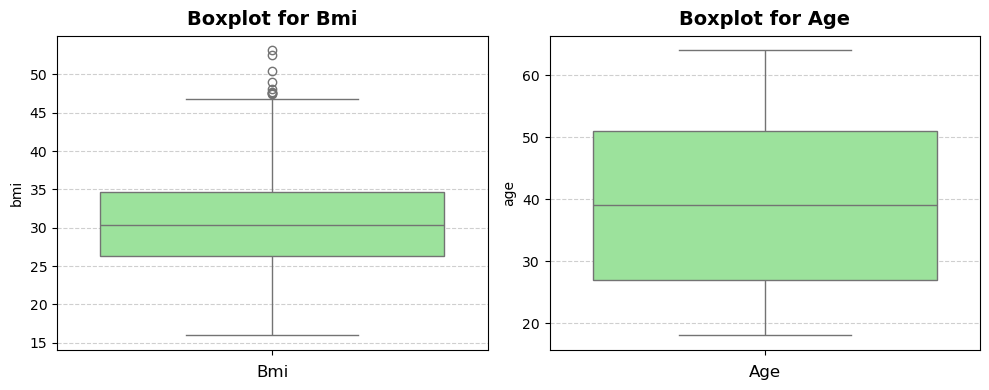

In [13]:
# Set the size of the plots 
plt.figure(figsize = (10, 4)) 

# Boxplots to check for outliers in BMI and Age 
for i, col in enumerate(["bmi", "age"], 1): 
    plt.subplot(1, 2, i)   # 1 row, 2 columns layout
    sns.boxplot(data[col], color = "lightgreen") 
    plt.title(f"Boxplot for {col.capitalize()}", fontsize = 14, fontweight = "bold", pad = 8) 
    plt.xlabel(col.capitalize(), fontsize = 12) 
    plt.grid(axis = "y", linestyle = "--", alpha = 0.6) 

plt.tight_layout() 
plt.show() 

- The **Age** feature does not show significant outliers, as values fall within a reasonable range (18–64).  
- The **BMI** feature shows a few potential outliers above 50, which represent individuals with very high BMI values.  
- These outliers are worth noting, as they may influence model performance if not handled. 

### Multivariate Analysis 

#### Checking for Correlation(Correlation Matrix) 

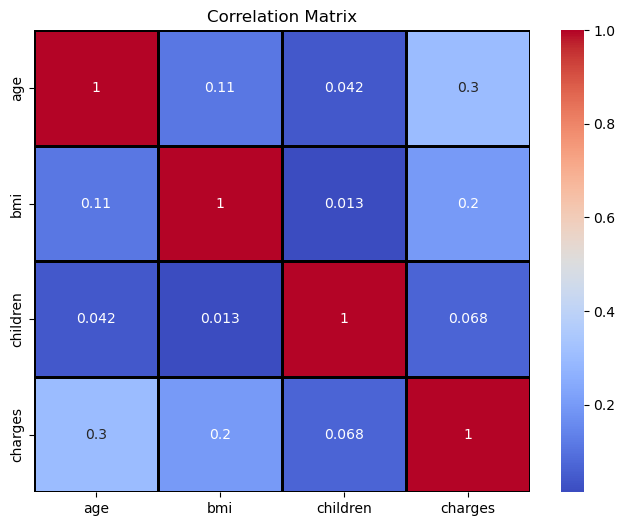

In [14]:
# Set the overall figure size 
plt.figure(figsize=(8, 6)) 

# Select only numerical columns from the dataset for correlation analysis 
numerical_cols = data.select_dtypes(include = ["int", "float"]) 

# Plot a heatmap showing correlations between numerical features 
sns.heatmap(numerical_cols.corr(), annot = True, cmap = "coolwarm", linewidths = 1, linecolor = "black") 

# Add a title to the heatmap 
plt.title("Correlation Matrix") 

plt.show() 

- The correlation heatmap shows that **insurance charges are strongly correlated with smoking (categorical, not in heatmap)**, and among numerical variables:  
  - **Age** and **BMI** have a **moderate positive correlation** with charges.  
  - **Children** shows almost **no correlation** with charges.  
- No strong multicollinearity is observed among the independent numerical features, so all can be retained for modeling. 

## Data Preprocessing 

### Data Cleaning 

#### Checking Duplicate Values 

In [15]:
data.duplicated().sum() # Counting duplicated rows 

1

In [16]:
data.drop_duplicates(inplace = True) # dropping duplicated rows 

#### Inspecting Categorical Columns for Unexpected or Inconsistent Values 

In [17]:
data["smoker"].unique() # Check the unique categories present in the 'smoker' column 

array(['yes', 'no'], dtype=object)

In [18]:
data["sex"].unique() # Check the unique categories present in the 'sex' column 

array(['female', 'male'], dtype=object)

In [19]:
data["region"].unique() # Check the unique categories present in the 'region' column 

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

#### Inspecting Numeric Columns to Ensure there are No Negative or Zero Values 

In [20]:
data[data["age"] <= 0] # Filter rows where 'age' is less than or equal to 0 (invalid ages) 

,age,sex,bmi,children,smoker,region,charges


In [21]:
data[data["bmi"] <= 0] # Filter rows where 'BMI' is less than or equal to 0 (invalid values) 

,age,sex,bmi,children,smoker,region,charges


## Handling Outliers 

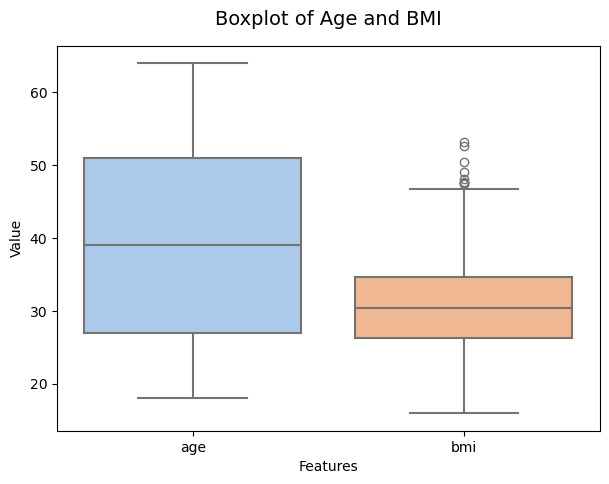

In [22]:
# Set the size of the plot 
plt.figure(figsize = (7,5))

# Boxplots for 'age' and 'bmi' together to check their distributions & outliers 
sns.boxplot(data = data[["age", "bmi"]], palette = "pastel", width = 0.8, linewidth = 1.5)
plt.title("Boxplot of Age and BMI", fontsize = 14, pad = 15)
plt.ylabel("Value")
plt.xlabel("Features")
plt.show() 

#### Handling outliers through IQR Method 

In [23]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile) for 'bmi'
Q1 = data["bmi"].quantile(0.25)
print("Q1:", Q1)

Q3 = data["bmi"].quantile(0.75)
print("Q3:", Q3)

# Interquartile Range (spread of middle 50%)
IQR = Q3 - Q1
print("IQR (Q3 - Q1):", IQR)

# Define boundaries for detecting outliers
lower_boundary = Q1 - 1.5 * IQR
print("Lower Boundary:", lower_boundary)

upper_boundary = Q3 + 1.5 * IQR
print("Upper Boundary:", upper_boundary)

# Replace outliers (values above upper boundary) with median of 'bmi'
data.loc[data["bmi"] > upper_boundary, "bmi"] = data["bmi"].median()


Q1: 26.29
Q3: 34.7
IQR (Q3 - Q1): 8.410000000000004
Lower Boundary: 13.674999999999994
Upper Boundary: 47.31500000000001


## Feature Engineering (New Features) 

In [24]:
# Creating BMI category feature to capture non-linear effect bins 
def bmi_category(bmi):
    # Creating categorical label based on standard BMI ranges 
    if bmi < 18.5:
        return "Underweight"
    elif 18.5 <= bmi < 25:
        return "Normal"
    elif 25 <= bmi < 30:
        return "Overweight"
    else:
        return "Obese"

data['bmi_category'] = data['bmi'].apply(bmi_category) 

**A new column bmi_category has been created by converting the continuous BMI values into health-related categories (Underweight, Normal, Overweight, Obese). This helps the model capture the non-linear impact of BMI on insurance charges more effectively.** 

In [25]:
# Adding squared term to capture curvature 
data["age2"] = data["age"] ** 2 

**A new column age2 has been created by squaring the age column. This feature helps capture non-linear effects of age on insurance charges, as the increase in charges with age is not always perfectly linear (especially for older individuals).** 

In [26]:
 # Creating smoker-bmi interaction (boolean multiply) 
data['bmi_smoker_interaction'] = data['bmi'] * (data['smoker'] == 'yes').astype(int) 

**A new column bmi_smoker_interaction has been created to capture the combined effect of smoking and BMI. This interaction feature helps the model learn that high BMI has a much stronger impact on insurance charges for smokers compared to non-smokers.** 

## Encoding Categorical Variables 

In [27]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder # Importing required library/module 

In [28]:
data.head()  # Showing first few rows for a quick glance at structure 

,age,sex,bmi,children,smoker,region,charges,bmi_category,age2,bmi_smoker_interaction
0,19,female,27.900,0,yes,southwest,16884.92400,Overweight,361,27.9
1,18,male,33.770,1,no,southeast,1725.55230,Obese,324,0.0
2,28,male,33.000,3,no,southeast,4449.46200,Obese,784,0.0
3,33,male,22.705,0,no,northwest,21984.47061,Normal,1089,0.0
4,32,male,28.880,0,no,northwest,3866.85520,Overweight,1024,0.0


In [29]:
# One-hot encoding selected categorical columns (dropping first to avoid dummy trap) 
OHE_enc = OneHotEncoder() 
data = pd.get_dummies(data, columns = ["region", "sex", "bmi_category"], dtype = int, drop_first = True) 

In [30]:
# Label-encoding smoker (binary) to 0/1 for downstream models 
label_enc = LabelEncoder() 
data["smoker"] = label_enc.fit_transform(data["smoker"]) 

## Spliting data into training and testing 

In [31]:
# Split the dataset into features (x) and target variable (y). 
x = data.drop("charges", axis = 1) # x contains all the columns except 'charges' (the target variable). 
y = data["charges"] # y contains only the 'charges' column, which is the target variable that the model will predict. 

In [32]:
from sklearn.model_selection import train_test_split 
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state = 42, test_size = 0.20) 
# x_train and y_train will be used to train the model, while x_test and y_test will be used for evaluation. 
# The test size is set to 20% of the data (test_size = 0.20), meaning 80% will be used for training. 
# random_state = 42 ensures that the split is reproducible. Using the same random_state will give the same split every time. 

## Scaling 

In [33]:
from sklearn.preprocessing import StandardScaler # Importing required library/module 

In [34]:
 # Selecting continuous features for scaling 
con_cols = ["age", "bmi", "age2", "bmi_smoker_interaction"] 

# Scaling/normalizing features 
std_scaler = StandardScaler() 
x_train[con_cols] = std_scaler.fit_transform(x_train[con_cols]) 
x_test[con_cols] = std_scaler.transform(x_test[con_cols]) 

In [35]:
data.head() # Showing first few rows for a quick glance at structure 

,age,bmi,children,smoker,charges,age2,bmi_smoker_interaction,region_northwest,region_southeast,region_southwest,sex_male,bmi_category_Obese,bmi_category_Overweight,bmi_category_Underweight
0,19,27.900,0,1,16884.92400,361,27.9,0,0,1,0,0,1,0
1,18,33.770,1,0,1725.55230,324,0.0,0,1,0,1,1,0,0
2,28,33.000,3,0,4449.46200,784,0.0,0,1,0,1,1,0,0
3,33,22.705,0,0,21984.47061,1089,0.0,1,0,0,1,0,0,0
4,32,28.880,0,0,3866.85520,1024,0.0,1,0,0,1,0,1,0


## Model Creation and Evaluation 

In [36]:
# Importing various regression models from sklearn to apply different machine learning algorithms for regression tasks.

# LinearRegression: A basic linear regression model for predicting continuous variables.
from sklearn.linear_model import LinearRegression 

# DecisionTreeRegressor: A non-linear model that uses a decision tree for regression tasks.
from sklearn.tree import DecisionTreeRegressor

# RandomForestRegressor: An ensemble model that creates multiple decision trees and averages their predictions to reduce overfitting.
from sklearn.ensemble import RandomForestRegressor

# GradientBoostingRegressor: A boosting algorithm that builds trees sequentially, where each tree corrects the errors of the previous one.
from sklearn.ensemble import GradientBoostingRegressor

# AdaBoostRegressor: An ensemble technique that builds a strong model by combining weak learners sequentially.
from sklearn.ensemble import AdaBoostRegressor

# SVR (Support Vector Regression): Uses support vector machines for regression tasks, focusing on finding a margin of tolerance for predictions.
from sklearn.svm import SVR

# KNeighborsRegressor: A non-parametric model that makes predictions based on the average of the k-nearest neighbors in the feature space.
from sklearn.neighbors import KNeighborsRegressor 

In [37]:
# Importing regression metrics from sklearn to evaluate model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 

In [38]:
# Function to evaluate models on training and testing sets
def evaluate_model(model, x_train, y_train, x_test, y_test):
    # Fit (train) the model on training data
    model.fit(x_train, y_train) 
    
    # Predict on training data
    y_train_pred = model.predict(x_train) 
    
    # Predict on testing data
    y_test_pred = model.predict(x_test) 
    
    # Calculate R² (coefficient of determination) for training set
    r2_train = r2_score(y_train, y_train_pred) 
    
    # Calculate R² for testing set
    r2_test = r2_score(y_test, y_test_pred) 
    
    # Calculate error metrics on test set
    mae = mean_absolute_error(y_test, y_test_pred)        # Mean Absolute Error
    mse = mean_squared_error(y_test, y_test_pred)         # Mean Squared Error
    rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))  # Root Mean Squared Error
    
    # Return all metrics
    return r2_train, r2_test, mae, mse, rmse 


# Dictionary containing different regression models
models = {
    "Linear Regression": LinearRegression(), 
    "Random Forest": RandomForestRegressor(random_state=42), 
    "Gradient Boosting": GradientBoostingRegressor(random_state=42), 
    "Decision Tree": DecisionTreeRegressor(random_state=42), 
    "Support Vector Regressor": SVR(), 
    "KNeighbors Regressor": KNeighborsRegressor() 
} 


# Dictionary to store results
results = {} 

# Train and evaluate each model
for name, model in models.items():
    # Get evaluation metrics
    r2_train, r2_test, mae, mse, rmse = evaluate_model(model, x_train, y_train, x_test, y_test) 
    
    # Save results in dictionary
    results[name] = {
        "R2_Score_Train": r2_train,
        "R2_Score_Test": r2_test,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse
    } 


# Convert results dictionary into a DataFrame for easy visualization
results_df = pd.DataFrame(results).T  # .T transposes rows ↔ columns
results_df 

,R2_Score_Train,R2_Score_Test,MAE,MSE,RMSE
Linear Regression,0.834086,0.869619,2900.109129,2.395824e+07,4894.715874
Random Forest,0.973617,0.883020,2650.966779,2.149579e+07,4636.355600
Gradient Boosting,0.891637,0.900936,2483.886085,1.820360e+07,4266.567983
Decision Tree,1.000000,0.811079,2724.970791,3.471544e+07,5891.981036
Support Vector Regressor,-0.095224,-0.128678,9235.787566,2.074014e+08,14401.438910
KNeighbors Regressor,0.882063,0.876361,2748.314253,2.271947e+07,4766.494730


## Baseline Model Performance Report (Before Tuning) 
In total, 6 models were trained on this dataset to predict the insurance charges for various individuals on the basis of their demographic and health information. This evaluation is the baseline model performance to set the benchmark and to identify the appropriate algorithms for further optimization. 

- **Best Baseline Model, Gradient Boosting** emerged as the best algorithm compared to others with highest R2 test score of 0.90 and with the lowest MAE of ~2483 (and RMSE of ~4266), making it the most accurate among untuned models. 

- **Random Forest** too performed well with R2 test score of 0.88 and relatively lower metrics but goes towards overfitting. After tuning, the results may improve. 

- **Decision Tree** performed poorly with R2 test score of 0.80 but goes heavily towards overfitting with training R2 score of 1.00.  

- **Support Vector Regressor** showed negative value of R2 test score i.e. -0.12 indicating very poor performance on this dataset. 

- **KNeighbors Regressor** gave moderate performance with an R2 test score of 0.87, although better than Linear Regression but not as strong as Gradient Boosting and Random Forest. 

- **Linear Regression** performed consistently with R2 test score of 0.86. 

## Hyperparameter Tuning to Enhance Model Performance 

In [36]:
from sklearn.model_selection import GridSearchCV # Importing required library/module 

#### For Random Forest Regressor: 

In [40]:
# Import and initialize Random Forest Regressor with a fixed random state for reproducibility
rf_model = RandomForestRegressor(random_state=42) 

# Define the parameter grid for hyperparameter tuning
rf_param_grid = { 
    "n_estimators" : [300, 350, 400, 450, 500],   # Number of trees in the forest
    "max_depth" : [6, 7, 8, 10],                  # Maximum depth of each tree
    "min_samples_split" : [2, 3, 4, 5, 6],        # Minimum samples required to split a node
    "min_samples_leaf" : [2, 3, 4, 5],            # Minimum samples required at a leaf node
    "max_features" : ["auto", "sqrt", "log2"]     # Number of features considered at each split
} 

# Perform GridSearchCV for hyperparameter tuning
rf_gridsearch_model = GridSearchCV(
    estimator = rf_model, 
    param_grid = rf_param_grid, 
    verbose = 3,                                  # Print progress during search
    refit = True,                                 # Refit model with best parameters after search
    cv = 3,                                       # 3-fold cross-validation
    scoring = "neg_mean_absolute_error",           # Evaluation metric
    n_jobs = -1                                   # Use all CPU cores for faster computation
) 

# Fit the GridSearch model on training data
rf_gridsearch_model.fit(x_train, y_train) 

# Print the best parameters found by GridSearchCV
print("Best params :", rf_gridsearch_model.best_params_) 


# ---- Predictions ----
rf_y_pred_tuned = rf_gridsearch_model.predict(x_test)      # Predictions on test data
rf_y_pred_tuned_train = rf_gridsearch_model.predict(x_train)  # Predictions on train data


# ---- Metrics for tuned Random Forest ----
rf_tuned_metrics = { 
    "R2_Score_Train": r2_score(y_train, rf_y_pred_tuned_train),      # R² score on training data
    "R2_Score_Test": r2_score(y_test, rf_y_pred_tuned),              # R² score on test data
    "MAE": mean_absolute_error(y_test, rf_y_pred_tuned),             # Mean Absolute Error
    "MSE": mean_squared_error(y_test, rf_y_pred_tuned),              # Mean Squared Error
    "RMSE": np.sqrt(mean_squared_error(y_test, rf_y_pred_tuned))     # Root Mean Squared Error
} 

# Convert metrics dictionary into a DataFrame for better readability
rf_tuned_df = pd.DataFrame([rf_tuned_metrics], index=["Random Forest (Tuned)"]) 

# Display results
rf_tuned_df 

Fitting 3 folds for each of 1200 candidates, totalling 3600 fits
Best params : {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 450}


,R2_Score_Train,R2_Score_Test,MAE,MSE,RMSE
Random Forest (Tuned),0.898862,0.89392,2524.946246,1.949275e+07,4415.059941


#### For Gradient Boosting Regressor: 

In [41]:
# Importing Gradient Boosting Regressor model
gb_model = GradientBoostingRegressor(random_state=42)

# Defining the parameter grid for GridSearchCV (Hyperparameter tuning)
gb_param_grid = {
    "n_estimators": [250, 300, 350, 400, 500],     # Number of boosting stages (trees)
    "learning_rate": [0.01, 0.02, 0.03, 0.04],     # Shrinks contribution of each tree
    "max_depth": [2, 3, 5],                        # Maximum depth of individual trees
    "min_samples_split": [2, 4, 6],                # Minimum samples required to split a node
    "min_samples_leaf": [2, 3, 4],                 # Minimum samples required at a leaf node
    "max_features": ["sqrt", "log2"]               # Number of features considered for best split
}

# Performing GridSearchCV for hyperparameter tuning
# - cv = 3 → 3-fold cross validation
# - scoring = 'neg_mean_squared_error' (because lower MSE = better model)
# - verbose = 3 → detailed logs while training
# - n_jobs = -1 → use all CPU cores for faster training
gb_gridsearch_model = GridSearchCV(
    estimator=gb_model,
    param_grid=gb_param_grid,
    verbose=3,
    refit=True,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

# Fit GridSearchCV model on training data
gb_gridsearch_model.fit(x_train, y_train)

# Print the best set of parameters found by GridSearchCV
print("Best params :", gb_gridsearch_model.best_params_)

# Predict on test and train data using the tuned Gradient Boosting model
gb_y_pred_tuned = gb_gridsearch_model.predict(x_test)
gb_y_pred_tuned_train = gb_gridsearch_model.predict(x_train)

# ---- Metrics for Tuned Gradient Boosting ----
gb_tuned_metrics = {
    "R2_Score_Train": r2_score(y_train, gb_y_pred_tuned_train),   # R² score for training set
    "R2_Score_Test": r2_score(y_test, gb_y_pred_tuned),           # R² score for test set
    "MAE": mean_absolute_error(y_test, gb_y_pred_tuned),          # Mean Absolute Error
    "MSE": mean_squared_error(y_test, gb_y_pred_tuned),           # Mean Squared Error
    "RMSE": np.sqrt(mean_squared_error(y_test, gb_y_pred_tuned))  # Root Mean Squared Error
}

# Store metrics in a DataFrame for better readability
gb_tuned_df = pd.DataFrame([gb_tuned_metrics], index=["Gradient Boosting (Tuned)"])
gb_tuned_df 

Fitting 3 folds for each of 1080 candidates, totalling 3240 fits
Best params : {'learning_rate': 0.03, 'max_depth': 2, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 500}


,R2_Score_Train,R2_Score_Test,MAE,MSE,RMSE
Gradient Boosting (Tuned),0.870636,0.90043,2440.331206,1.829660e+07,4277.452388


In [42]:
# Combine (stack) the previous results DataFrame with the new tuned model results
results_df = pd.concat([results_df, rf_tuned_df, gb_tuned_df]) 

# Display the final results DataFrame
results_df 

,R2_Score_Train,R2_Score_Test,MAE,MSE,RMSE
Linear Regression,0.834086,0.869619,2900.109129,2.395824e+07,4894.715874
Random Forest,0.973617,0.883020,2650.966779,2.149579e+07,4636.355600
Gradient Boosting,0.891637,0.900936,2483.886085,1.820360e+07,4266.567983
Decision Tree,1.000000,0.811079,2724.970791,3.471544e+07,5891.981036
Support Vector Regressor,-0.095224,-0.128678,9235.787566,2.074014e+08,14401.438910
KNeighbors Regressor,0.882063,0.876361,2748.314253,2.271947e+07,4766.494730
Random Forest (Tuned),0.898862,0.893920,2524.946246,1.949275e+07,4415.059941
Gradient Boosting (Tuned),0.870636,0.900430,2440.331206,1.829660e+07,4277.452388


## Baseline Model Performance Report (After Tuning) 

Two models i.e. **Gradient Boosting Regressor** and **Random Forest Regressor** were tuned on different parameters to further try to modify the algorithms and gain more accurate results. 

- **Gradient Boosting** maintained a strong hold with a `Test R2 of 0.90` and achieved the `lowest MAE of ~2440`, along with a competitive `RMSE of ~4292.` 

- **Random Forest** improved over its baseline performance, achieving a `Test R2 of 0.89` (0.88 earlier) and `lowering Training R2 from 0.97 to 0.88`, which reduced overfitting. It also achieved an improved `MAE of ~2525` (compared to ~2685 earlier), and `RMSE dropped from ~4668 to ~4421`, helping the model generalize better. 

## Conclusion 

Overall, the tuning process led to better generalization of models and more meaningful gains in terms of accuracy and reduced the error for top-performing algorithms. Gradient Boosting remained the best choice in terms of lowest MAE (and competitive RMSE), while Random Forest improved its balance between bias and variance with reduced overfitting. 

## Challenges Faced

While working on the insurance dataset for predictive modeling, several challenges were encountered during data cleaning, preprocessing, feature engineering, and model building. These challenges required careful handling to ensure the accuracy and reliability of the results.

1. **Data Quality and Outliers:** 
Although the dataset did not contain missing values, there were outliers in the `bmi` column. These extreme values required careful handling, as they could negatively impact model performance.

2. **Feature Engineering:**
The initial features did not provide a clear representation of patterns in the data. To make the dataset more interpretable and improve model performance, new derived features were created and existing ones were modified.

3. **Skewed Target Variable:**
The target variable `charges` was highly right-skewed, with a small group of individuals incurring very high medical costs. As a result, the model performed reasonably well for the majority of cases but struggled to predict extreme values accurately.

4. **Overfitting vs. Underfitting:**
Some models, such as `Decision Tree` and `Random Forest`, initially showed signs of overfitting, while simpler models tended to underfit. Hyperparameter tuning was applied to Random Forest to achieve a better balance between training and testing accuracy.

5. **Hyperparameter Tuning Limitations:**
Hyperparameter tuning using GridSearchCV helped in reducing overfitting and improving generalization. However, it did not significantly improve the test set performance in terms of the R² score, highlighting limitations in model selection and dataset complexity. 

**Conclusion:** 
Addressing these challenges improved data quality, reduced bias, and led to more reliable predictions. Although some limitations remain, overcoming these hurdles enhanced my understanding of data preprocessing, feature engineering, and model evaluation in real-world scenarios. 